<a href="https://colab.research.google.com/github/MarriRohan/6G-RL-Edge-Caching/blob/main/6g%20dqn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reproduce the network model

In [ ]:
pip install numpy matplotlib pandas networkx scipy

implement content requests

In [ ]:
import numpy as np

NUM_USERS = 20
NUM_CONTENT = 100

requests = np.random.randint(0, NUM_CONTENT, NUM_USERS)

cache1 = [1,5,8,10]

for content in requests:
    if content in cache1:
        delay = 1
    else:
        delay = 10

    print(f"Content={content}, Delay={delay}")

Content=8, Delay=1
Content=91, Delay=10
Content=93, Delay=10
Content=39, Delay=10
Content=81, Delay=10
Content=4, Delay=10
Content=40, Delay=10
Content=43, Delay=10
Content=67, Delay=10
Content=38, Delay=10
Content=36, Delay=10
Content=8, Delay=1
Content=48, Delay=10
Content=70, Delay=10
Content=7, Delay=10
Content=47, Delay=10
Content=53, Delay=10
Content=9, Delay=10
Content=42, Delay=10
Content=29, Delay=10


Cache Placement

In [ ]:
import numpy as np

NUM_USERS = 20
NUM_CONTENT = 100

requests = np.random.randint(0, NUM_CONTENT, NUM_USERS)

cache1 = [1, 5, 8, 10]

cache_hits = 0
delays = []

for content in requests:
    if content in cache1:
        cache_hits += 1
        delays.append(1)     # Edge Cache delay
    else:
        delays.append(10)    # Cloud delay

hit_ratio = cache_hits / len(requests)
avg_delay = np.mean(delays)

print("Cache Hits =", cache_hits)
print("Cache Hit Ratio =", hit_ratio)
print("Average Delay =", avg_delay)

Cache Hits = 0
Cache Hit Ratio = 0.0
Average Delay = 10.0


Paper Metrics

In [ ]:
import numpy as np

total_bits = len(requests) * 1000   # 1000 bits per request
simulation_time = sum(delays)

throughput = total_bits / simulation_time

print("Throughput =", throughput)

Throughput = 100.0


Energy Efficiency

In [ ]:
total_power = 50  # Watts

energy_efficiency = throughput / total_power

print("Energy Efficiency =", energy_efficiency)

Energy Efficiency = 2.0


Visualization

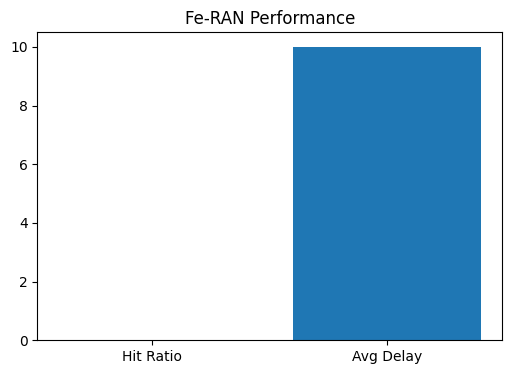

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(
    ["Hit Ratio", "Avg Delay"],
    [hit_ratio, avg_delay]
)
plt.title("Fe-RAN Performance")
plt.show()

RL Libraries

In [ ]:
!pip install gymnasium stable-baselines3 torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 10.2 MB/s eta 0:00:00


FeRAN Environment

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class FeRANEnv(gym.Env):

    def __init__(self):
        super().__init__()

        self.num_users = 20
        self.num_contents = 100
        self.num_caches = 3
        self.cache_size = 30

        self.action_space = spaces.Discrete(
            self.num_contents * self.num_caches
        )
        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(200,),
            dtype=np.float32
        )

        self.reset()

    def reset(self, seed=None, options=None):
      # Zipf popularity distribution
      ranks = np.arange(1, self.num_contents + 1)

      self.popularity = 1 / ranks
      self.popularity /= self.popularity.sum()

      self.caches = {
          0: [],
          1: [],
          2: []
      }

      cache_state = np.zeros(self.num_contents)


      for cache in self.caches.values():
        for item in cache:
          cache_state[item]=1
      state = np.concatenate([
          self.popularity,
          cache_state
      ])

      return state.astype(np.float32), {}

    def step(self, action):

        content = action // self.num_caches
        cache_id = action % self.num_caches

        if content not in self.caches[cache_id]:
            if len(self.caches[cache_id]) < self.cache_size:
                self.caches[cache_id].append(content)
        requests = np.random.choice(
            self.num_contents,
            size=self.num_users,
            p=self.popularity
        )

        cache_hits = 0
        delays = []

        for content in requests:

            hit = False

            for cache in self.caches.values():
              if content in cache:
                hit = True
                break

            if hit:
                cache_hits += 1
                delays.append(1)
            else:
                delays.append(10)

        hit_ratio = cache_hits / len(requests)

        avg_delay = np.mean(delays)

        throughput = (
            len(requests) * 1000
        ) / np.sum(delays)

        power = 50

        energy_efficiency = throughput / power

        cache_state = np.zeros(self.num_contents)

        reward = (
            20 * hit_ratio
            - 0.05 * avg_delay
            + 2*energy_efficiency
        )

        for cache in self.caches.values():
          for item in cache:
            cache_state[item] = 1
        state = np.concatenate([
            self.popularity,
            cache_state
        ])

        return (
            state.astype(np.float32),
            reward,
            False,
            False,
            {
                "hit_ratio": hit_ratio,
                "delay": avg_delay,
                "throughput": throughput,
                "ee": energy_efficiency
            }
        )

In [ ]:
import gymnasium as gym
from gymnasium import spaces

class FeRANEnv(gym.Env):

    def __init__(self):
        super().__init__()

        self.action_space = spaces.Discrete(10)
        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(200,)
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        return [0,0,0,0,0], {}

    def step(self, action):
        return [0,0,0,0,0], 1.0, False, False, {}

env = FeRANEnv()

state, _ = env.reset()

print("State =", state)
print("Environment Works")

State = [0, 0, 0, 0, 0]
Environment Works


TESTING

In [ ]:
env = FeRANEnv()

state, _ = env.reset()

action = env.action_space.sample()

next_state, reward, done, trunc, info = env.step(action)

print(info)

{'hit_ratio': 0.0, 'delay': np.float64(10.0), 'throughput': np.float64(100.0), 'ee': np.float64(2.0)}


In [ ]:
env = FeRANEnv()

state, _ = env.reset()

print(state.shape)

(200,)


In [ ]:
env = FeRANEnv()

state, _ = env.reset()

print("State Shape =", state.shape)

action = env.action_space.sample()

next_state, reward, done, trunc, info = env.step(action)

print(info)

State Shape = (200,)
{'hit_ratio': 0.0, 'delay': np.float64(10.0), 'throughput': np.float64(100.0), 'ee': np.float64(2.0)}


Train DQN

In [ ]:
from stable_baselines3 import DQN

env = FeRANEnv()

model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=1e-3
)

model.learn(
    total_timesteps=100000
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [ ]:
print(env.caches)

{0: [np.int64(85), np.int64(23), np.int64(4), np.int64(60), np.int64(26), np.int64(58), np.int64(22), np.int64(98), np.int64(70), np.int64(59), np.int64(99), np.int64(2), np.int64(96), np.int64(79), np.int64(50), np.int64(9), np.int64(91), np.int64(51), np.int64(94), np.int64(12), np.int64(90), np.int64(86), np.int64(54), np.int64(19), np.int64(13), np.int64(83), np.int64(72), np.int64(34), np.int64(20), np.int64(64)], 1: [np.int64(36), np.int64(34), np.int64(22), np.int64(80), np.int64(94), np.int64(70), np.int64(72), np.int64(73), np.int64(17), np.int64(91), np.int64(59), np.int64(45), np.int64(53), np.int64(30), np.int64(19), np.int64(60), np.int64(8), np.int64(95), np.int64(71), np.int64(57), np.int64(18), np.int64(3), np.int64(46), np.int64(76), np.int64(10), np.int64(6), np.int64(28), np.int64(52), np.int64(9), np.int64(48)], 2: [np.int64(97), np.int64(9), np.int64(94), np.int64(29), np.int64(76), np.int64(62), np.int64(2), np.int64(56), np.int64(86), np.int64(17), np.int64(66), 

Evaluate

In [ ]:
state, _ = env.reset()

rewards = []
hits = []
delays = []
throughputs = []
ees = []

for _ in range(200):

    action, _ = model.predict(
        state,
        deterministic=True
    )

    state, reward, done, trunc, info = env.step(action)

    rewards.append(reward)
    hits.append(info["hit_ratio"])
    delays.append(info["delay"])
    throughputs.append(info["throughput"])
    ees.append(info["ee"])

print("Reward =", np.mean(rewards))
print("Hit Ratio =", np.mean(hits))
print("Delay =", np.mean(delays))
print("Throughput =", np.mean(throughputs))
print("Energy Efficiency =", np.mean(ees))

Reward = 3.5423843586387433
Hit Ratio = 0.0017499999999999998
Delay = 9.98425
Throughput = 100.16492146596858
Energy Efficiency = 2.0032984293193716


In [ ]:
requests = np.random.choice(
    env.num_contents,
    size=10000,
    p=env.popularity
)

unique, counts = np.unique(
    requests,
    return_counts=True
)

for i in range(10):
    print(unique[i], counts[i])

0 1927
1 981
2 637
3 498
4 370
5 331
6 271
7 230
8 201
9 200


In [ ]:
best_cache = list(range(30))

hits = 0

for content in requests:

    if content in best_cache:
        hits += 1

print("Hit Ratio =", hits/len(requests))

Hit Ratio = 0.7751


Compare Against Random Caching


In [ ]:
import numpy as np

random_hits = []

for _ in range(100):

    cache = np.random.choice(
        100,
        20,
        replace=False
    )

    requests = np.random.choice(
        100,
        20
    )

    hits = sum(
        [1 for r in requests if r in cache]
    )

    random_hits.append(
        hits / len(requests)
    )

print(
    "Random Hit Ratio =",
    np.mean(random_hits)
)

Random Hit Ratio = 0.19499999999999995


PAPER GRAPH

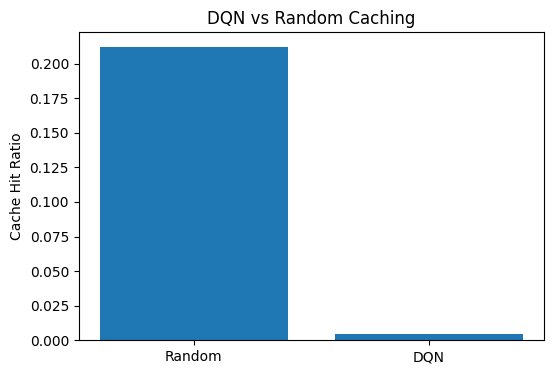

In [ ]:
import matplotlib.pyplot as plt

metrics = [
    np.mean(random_hits),
    np.mean(hits)
]

labels = [
    "Random",
    "DQN"
]

plt.figure(figsize=(6,4))
plt.bar(labels, metrics)
plt.ylabel("Cache Hit Ratio")
plt.title("DQN vs Random Caching")
plt.show()